# How to Train a RF-DETR Instance Segmentation Model with Custom Data

We will show you how to train a RF-DETR instance segmentation model with your images and annotations and export to a Core ML model which can be used for auto labeling on RectLabel.

### Use GPU

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Runtime` -> `Change runtime type` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Fri Mar 27 23:40:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              8W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install PyTorch 2.8.0

In [2]:
!pip install -q torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 MB 979.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 70.8 MB/s eta 0:00:00


### Install RF-DETR 1.5.1

In [3]:
!pip install -q rfdetr==1.5.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.9/187.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 118.8 MB/s eta 0:00:00


### Download training images and annotations

Download training images and annotations. You can use these or replace them with your own data.

In [4]:
!mkdir datasets
%cd datasets
!wget -q https://huggingface.co/datasets/rectlabel/datasets/resolve/main/donut_coco.zip
!unzip -q donut_coco.zip
%cd ..

/content/datasets
/content


### Fine-tune RF-DETR on custom dataset

Start training from the current content folder.

In [5]:
from rfdetr import RFDETRSegNano

model = RFDETRSegNano()
dataset_dir = "datasets/donut_coco"
model.train(dataset_dir=dataset_dir, epochs=10, batch_size=4, grad_accum_steps=4)

[2026-03-27 23:43:24] [INFO] rf-detr - Downloading pretrained weights for rf-detr-seg-nano.pt


rf-detr-seg-nano.pt:   0%|          | 0.00/128M [00:00<?, ?iB/s]

[2026-03-27 23:43:26] [INFO] rf-detr - MD5 validation successful for rf-detr-seg-nano.pt


[2026-03-27 23:43:26] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-27 23:43:26] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-27 23:43:26] [INFO] rf-detr - Loading pretrain weights


...

[2026-03-27 23:46:04] [INFO] rf-detr - Epoch: [6/10]  [0/5]  eta: 0:00:38  lr: 0.000100  class_error: 0.00  loss: 22.6008 (22.6008)  loss_ce: 2.3902 (2.3902)  loss_bbox: 0.1454 (0.1454)  loss_giou: 0.1529 (0.1529)  loss_mask_ce: 0.1345 (0.1345)  loss_mask_dice: 0.1554 (0.1554)  loss_ce_0: 4.9471 (4.9471)  loss_bbox_0: 0.1067 (0.1067)  loss_giou_0: 0.1120 (0.1120)  loss_mask_ce_0: 0.1332 (0.1332)  loss_mask_dice_0: 0.1348 (0.1348)  loss_ce_1: 3.3411 (3.3411)  loss_bbox_1: 0.0875 (0.0875)  loss_giou_1: 0.0986 (0.0986)  loss_mask_ce_1: 0.1395 (0.1395)  loss_mask_dice_1: 0.1593 (0.1593)  loss_ce_2: 3.1202 (3.1202)  loss_bbox_2: 0.1231 (0.1231)  loss_giou_2: 0.1283 (0.1283)  loss_mask_ce_2: 0.1454 (0.1454)  loss_mask_dice_2: 0.1970 (0.1970)  loss_ce_enc: 5.8226 (5.8226)  loss_bbox_enc: 0.2423 (0.2423)  loss_giou_enc: 0.1978 (0.1978)  loss_mask_ce_enc: 0.1692 (0.1692)  loss_mask_dice_enc: 0.2166 (0.2166)  loss_ce_unscaled: 0.4780 (0.4780)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_uns

[2026-03-27 23:46:30] [INFO] rf-detr - Epoch: [7/10]  [0/5]  eta: 0:00:35  lr: 0.000100  class_error: 0.00  loss: 20.5499 (20.5499)  loss_ce: 1.9021 (1.9021)  loss_bbox: 0.1593 (0.1593)  loss_giou: 0.1571 (0.1571)  loss_mask_ce: 0.1536 (0.1536)  loss_mask_dice: 0.1146 (0.1146)  loss_ce_0: 4.6174 (4.6174)  loss_bbox_0: 0.1241 (0.1241)  loss_giou_0: 0.1323 (0.1323)  loss_mask_ce_0: 0.1701 (0.1701)  loss_mask_dice_0: 0.1459 (0.1459)  loss_ce_1: 3.0715 (3.0715)  loss_bbox_1: 0.0991 (0.0991)  loss_giou_1: 0.1139 (0.1139)  loss_mask_ce_1: 0.1434 (0.1434)  loss_mask_dice_1: 0.1215 (0.1215)  loss_ce_2: 2.5174 (2.5174)  loss_bbox_2: 0.1274 (0.1274)  loss_giou_2: 0.1387 (0.1387)  loss_mask_ce_2: 0.1554 (0.1554)  loss_mask_dice_2: 0.1277 (0.1277)  loss_ce_enc: 5.1627 (5.1627)  loss_bbox_enc: 0.3622 (0.3622)  loss_giou_enc: 0.2834 (0.2834)  loss_mask_ce_enc: 0.2339 (0.2339)  loss_mask_dice_enc: 0.2151 (0.2151)  loss_ce_unscaled: 0.3804 (0.3804)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_uns

[2026-03-27 23:46:55] [INFO] rf-detr - Epoch: [8/10]  [0/5]  eta: 0:00:31  lr: 0.000100  class_error: -0.00  loss: 18.8109 (18.8109)  loss_ce: 1.7089 (1.7089)  loss_bbox: 0.1936 (0.1936)  loss_giou: 0.1911 (0.1911)  loss_mask_ce: 0.1196 (0.1196)  loss_mask_dice: 0.1453 (0.1453)  loss_ce_0: 4.1996 (4.1996)  loss_bbox_0: 0.1710 (0.1710)  loss_giou_0: 0.1611 (0.1611)  loss_mask_ce_0: 0.1174 (0.1174)  loss_mask_dice_0: 0.1679 (0.1679)  loss_ce_1: 2.7674 (2.7674)  loss_bbox_1: 0.1703 (0.1703)  loss_giou_1: 0.1552 (0.1552)  loss_mask_ce_1: 0.1271 (0.1271)  loss_mask_dice_1: 0.1581 (0.1581)  loss_ce_2: 2.0148 (2.0148)  loss_bbox_2: 0.1776 (0.1776)  loss_giou_2: 0.1620 (0.1620)  loss_mask_ce_2: 0.1157 (0.1157)  loss_mask_dice_2: 0.1439 (0.1439)  loss_ce_enc: 4.7225 (4.7225)  loss_bbox_enc: 0.2585 (0.2585)  loss_giou_enc: 0.2567 (0.2567)  loss_mask_ce_enc: 0.1643 (0.1643)  loss_mask_dice_enc: 0.2409 (0.2409)  loss_ce_unscaled: 0.3418 (0.3418)  class_error_unscaled: -0.0000 (-0.0000)  loss_bbox_

[2026-03-27 23:47:24] [INFO] rf-detr - Epoch: [9/10]  [0/5]  eta: 0:00:39  lr: 0.000100  class_error: 0.00  loss: 17.1790 (17.1790)  loss_ce: 1.5542 (1.5542)  loss_bbox: 0.1052 (0.1052)  loss_giou: 0.1721 (0.1721)  loss_mask_ce: 0.1164 (0.1164)  loss_mask_dice: 0.1787 (0.1787)  loss_ce_0: 3.8609 (3.8609)  loss_bbox_0: 0.1071 (0.1071)  loss_giou_0: 0.1622 (0.1622)  loss_mask_ce_0: 0.1071 (0.1071)  loss_mask_dice_0: 0.1774 (0.1774)  loss_ce_1: 2.5323 (2.5323)  loss_bbox_1: 0.0870 (0.0870)  loss_giou_1: 0.1416 (0.1416)  loss_mask_ce_1: 0.1036 (0.1036)  loss_mask_dice_1: 0.1574 (0.1574)  loss_ce_2: 1.9430 (1.9430)  loss_bbox_2: 0.1073 (0.1073)  loss_giou_2: 0.1703 (0.1703)  loss_mask_ce_2: 0.1015 (0.1015)  loss_mask_dice_2: 0.1451 (0.1451)  loss_ce_enc: 4.3185 (4.3185)  loss_bbox_enc: 0.1983 (0.1983)  loss_giou_enc: 0.2365 (0.2365)  loss_mask_ce_enc: 0.1282 (0.1282)  loss_mask_dice_enc: 0.2671 (0.2671)  loss_ce_unscaled: 0.3108 (0.3108)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_uns

[2026-03-27 23:47:52] [INFO] rf-detr - Epoch: [10/10]  [0/5]  eta: 0:00:37  lr: 0.000100  class_error: 0.00  loss: 17.4589 (17.4589)  loss_ce: 1.6806 (1.6806)  loss_bbox: 0.1632 (0.1632)  loss_giou: 0.1653 (0.1653)  loss_mask_ce: 0.1361 (0.1361)  loss_mask_dice: 0.1381 (0.1381)  loss_ce_0: 4.1628 (4.1628)  loss_bbox_0: 0.1270 (0.1270)  loss_giou_0: 0.1367 (0.1367)  loss_mask_ce_0: 0.1500 (0.1500)  loss_mask_dice_0: 0.1762 (0.1762)  loss_ce_1: 2.6617 (2.6617)  loss_bbox_1: 0.1462 (0.1462)  loss_giou_1: 0.1507 (0.1507)  loss_mask_ce_1: 0.1035 (0.1035)  loss_mask_dice_1: 0.1336 (0.1336)  loss_ce_2: 1.8977 (1.8977)  loss_bbox_2: 0.1550 (0.1550)  loss_giou_2: 0.1612 (0.1612)  loss_mask_ce_2: 0.1306 (0.1306)  loss_mask_dice_2: 0.1419 (0.1419)  loss_ce_enc: 3.7767 (3.7767)  loss_bbox_enc: 0.2596 (0.2596)  loss_giou_enc: 0.2527 (0.2527)  loss_mask_ce_enc: 0.2013 (0.2013)  loss_mask_dice_enc: 0.2506 (0.2506)  loss_ce_unscaled: 0.3361 (0.3361)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_un

Check training and validation loss.

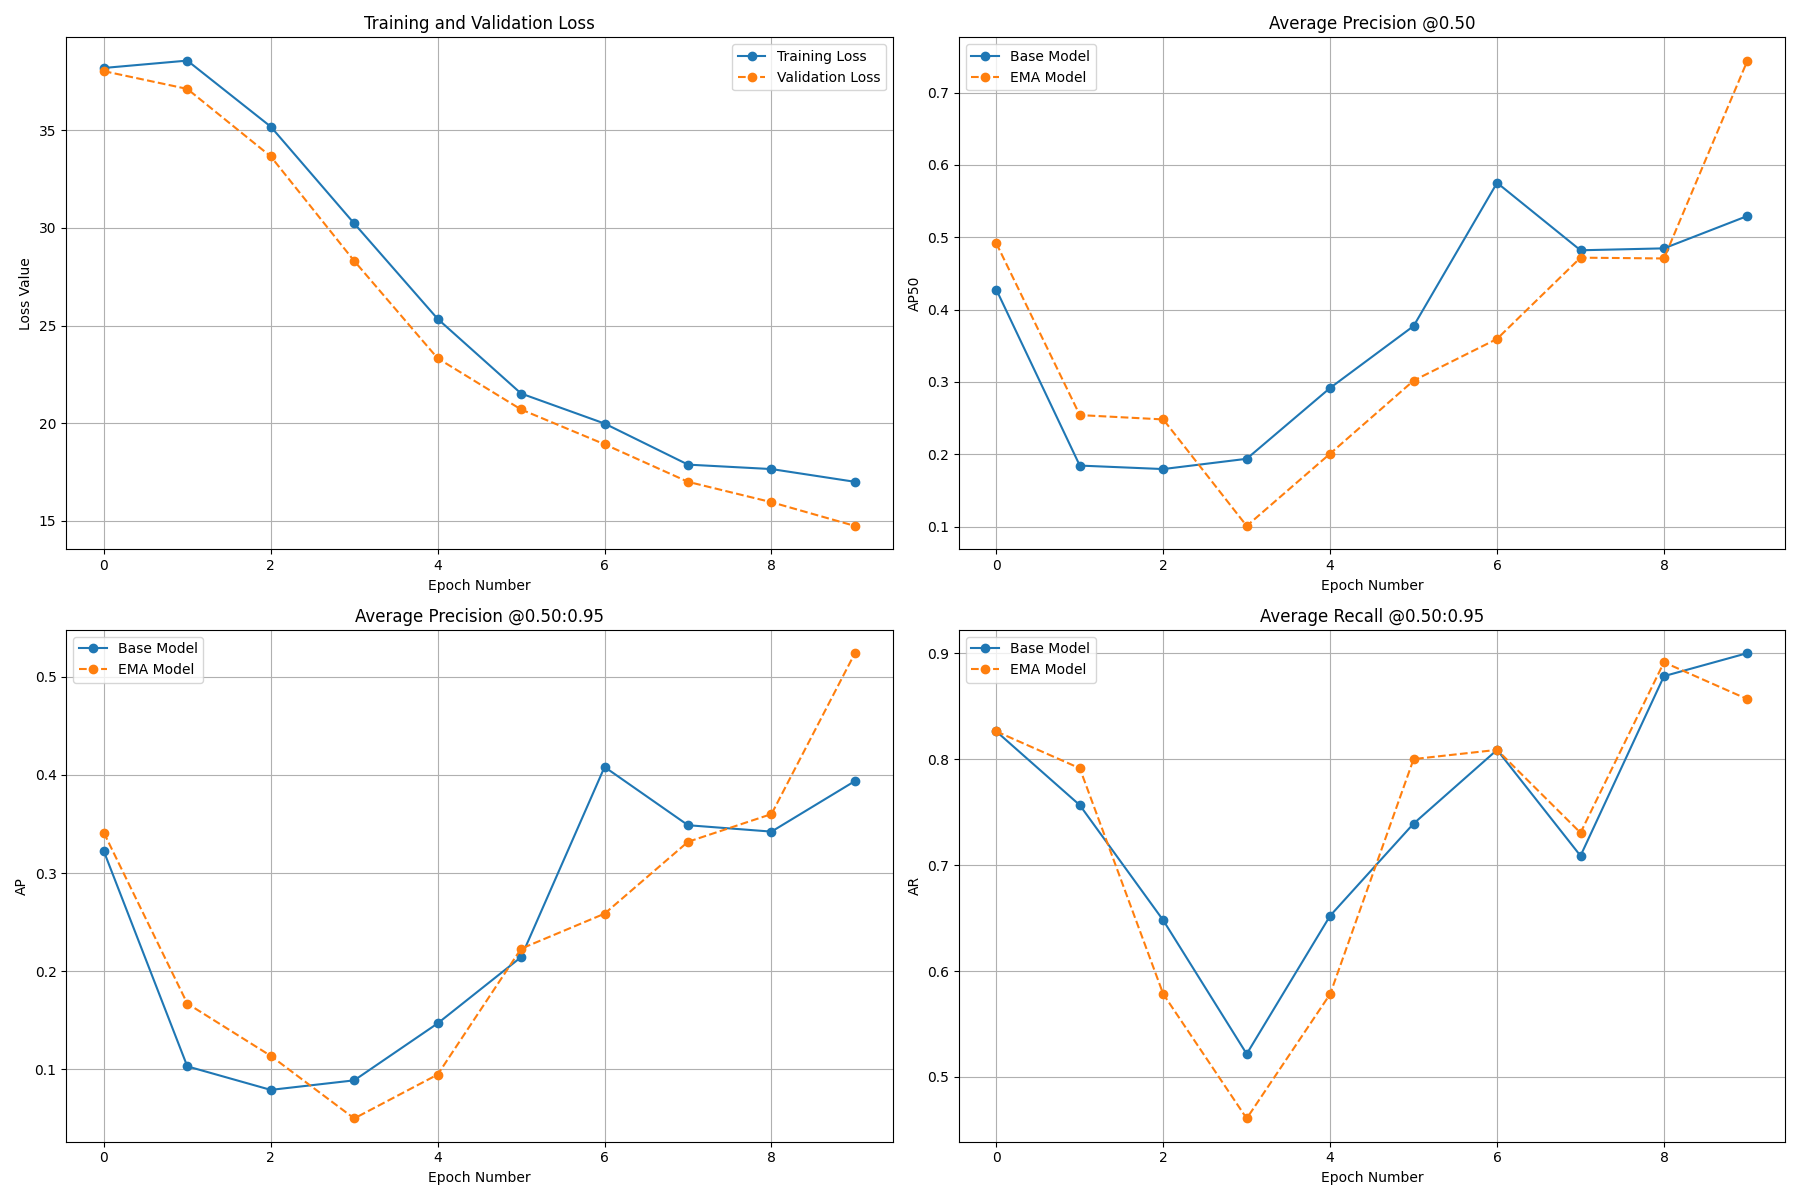

In [6]:
from PIL import Image

Image.open("/content/output/metrics_plot.png")

The trained model is checkpoint_best_total.pth.

In [7]:
!ls -la /content/output

total 1956472
drwxr-xr-x 3 root root      4096 Mar 27 23:48 .
drwxr-xr-x 1 root root      4096 Mar 27 23:43 ..
-rw-r--r-- 1 root root 534398511 Mar 27 23:48 checkpoint0009.pth
-rw-r--r-- 1 root root 399873726 Mar 27 23:48 checkpoint_best_ema.pth
-rw-r--r-- 1 root root 401162890 Mar 27 23:46 checkpoint_best_regular.pth
-rw------- 1 root root 133248663 Mar 27 23:48 checkpoint_best_total.pth
-rw-r--r-- 1 root root 534387619 Mar 27 23:48 checkpoint.pth
drwxr-xr-x 2 root root      4096 Mar 27 23:44 eval
-rw-r--r-- 1 root root      4412 Mar 27 23:48 events.out.tfevents.1774655007.bba42e46f9b5.8763.0
-rw-r--r-- 1 root root    112213 Mar 27 23:48 log.txt
-rw-r--r-- 1 root root    184522 Mar 27 23:48 metrics_plot.png
-rw-r--r-- 1 root root       823 Mar 27 23:48 results.json


### Install RF-DETR to CoreML

In [8]:
!git clone https://github.com/landchenxuan/rf-detr-to-coreml.git
%cd rf-detr-to-coreml
!pip install -q -e .

Cloning into 'rf-detr-to-coreml'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 99 (delta 38), reused 87 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (99/99), 1.71 MiB | 5.66 MiB/s, done.
Resolving deltas: 100% (38/38), done.
/content/rf-detr-to-coreml
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.9 MB/s eta 0:00:00
  Building editable for rfdetr-coreml (pyproject.toml) ... done


Move the best model to the current folder and export to a Core ML model.

In [9]:
!mv /content/output/checkpoint_best_total.pth .

In [10]:
!rfdetr-coreml --model seg-nano --weights checkpoint_best_total.pth

scikit-learn version 1.6.1 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
XGBoost version 3.2.0 has not been tested with coremltools. You may run into unexpected errors. XGBoost 1.4.2 is the most recent version that has been tested.
2026-03-27 23:49:17.071740: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774655357.107414   11508 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774655357.121193   11508 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774655357.153866   11508 computation_placer.cc:177] computation placer already registered. Please check linkage and 

In [11]:
!ls -la output

total 12
drwxr-xr-x 3 root root 4096 Mar 27 23:49 .
drwxr-xr-x 7 root root 4096 Mar 27 23:49 ..
drwxr-xr-x 3 root root 4096 Mar 27 23:49 rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage


In [12]:
%cd output

/content/rf-detr-to-coreml/output


Zip the Core ML model and download it from the File browser at the left hand. You can auto label images using the Core ML model on RectLabel.

In [13]:
!zip -r seg-nano.zip rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage

  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Manifest.json (deflated 59%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/model.mlmodel (deflated 89%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/weights/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/weights/weight.bin (deflated 7%)
